In [ ]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, TensorDataset, Dataset
from multi_unet_model_V2 import multi_unet_model1
import numpy as np
import sys
import glob
import os
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.patches as patches
import albumentations as A
from albumentations.pytorch import ToTensorV2

np.set_printoptions(threshold=sys.maxsize)

In [ ]:
#loading data and sizes
x_data_path = r'D:\OCT'
y_data_path = r'D:\masks'

SIZE_X = 240
SIZE_Y = 512
n_classes = 7
BATCH_SIZE = 16
EPOCHS = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


train_images.shape (198, 512, 240, 1)
<class 'numpy.ndarray'>


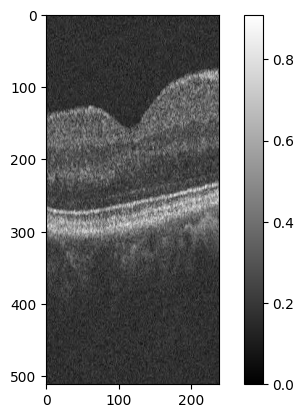

In [ ]:
#prepare training x (original) images
train_x_images = []

for directory_path in glob.glob(x_data_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (SIZE_X, SIZE_Y))
        train_x_images.append(img)

train_x_images = np.array(train_x_images, dtype=np.float32)   #using float32 for PyTorch
train_x_images = train_x_images / 255.0
train_x_images = np.expand_dims(train_x_images, axis=-1)

print("train_images.shape", train_x_images.shape)
print(type(train_x_images))

plt.imshow(train_x_images[0], cmap='gray')
plt.colorbar()

In [ ]:
#loading and checking y (masks) data
train_y_images = []

for directory_path in glob.glob(y_data_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (SIZE_X, SIZE_Y))
        train_y_images.append(img)

#cleaning masks for better training
cleaned_masks = []

for mask in train_y_images:
    mask = mask.squeeze()
    kernel = np.ones((3,3), np.uint8)

    # Remove small isolated pixels
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Fill small holes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # smooth boundaries
    mask = cv2.dilate(mask, kernel, iterations=1)
    mask = cv2.erode(mask, kernel, iterations=1)

    cleaned_masks.append(mask)

train_y_images = np.array(cleaned_masks, dtype=np.float32)   #using float32 for PyTorch
train_y_images = train_y_images / 255.0
train_y_images = np.expand_dims(train_y_images, axis=-1)

print("train_masks.shape", train_y_images.shape)
print(type(train_y_images))



train_masks.shape (1188, 512, 240, 1)
<class 'numpy.ndarray'>


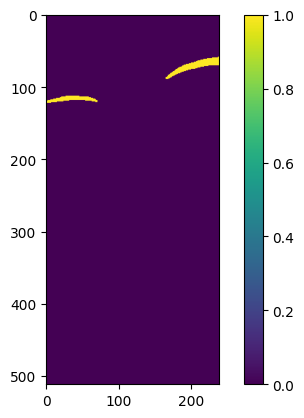

In [ ]:
plt.imshow(train_y_images[11,:,:, 0])
plt.colorbar()

(198, 512, 240, 7)
train_y_masks.shape (198, 512, 240, 7)


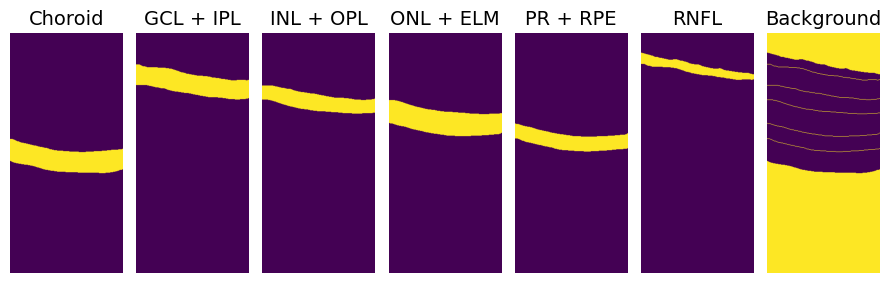

train_y_masks.shape (after processing) (198, 512, 240)
<class 'numpy.ndarray'>


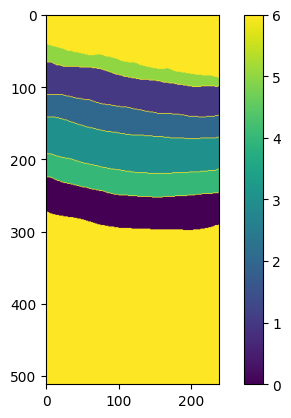

In [ ]:
# extra processing for masks, reducing number of masks to 1 mask per img
n_total_masks = train_y_images.shape[0]
n_samples = n_total_masks // 6

train_y_masks = np.zeros((n_samples,SIZE_Y,SIZE_X,7))
print(train_y_masks.shape)

for i in range(6):
    x = np.arange(i,n_samples*6,6)
    train_y_masks[:, :, :, i] = train_y_images[x,:,:,0]


train_y_masks[:, :, :, 6] = 1 - train_y_masks[:, :, :, :6].max(axis=-1)   # adding background as a class
print("train_y_masks.shape", train_y_masks.shape)

#visualise all 7 masks
class_names = [
    "Choroid",
    "GCL + IPL",
    "INL + OPL",
    "ONL + ELM",
    "PR + RPE",
    "RNFL",
    "Background"
]

fig, axs = plt.subplots(1, 7, figsize=(18, 3))
for i in range(7):
    axs[i].imshow(train_y_masks[8,:,:,i])  # <- visualise masks before argmax
    axs[i].set_title(f"{class_names[i]}", fontsize=14)
    axs[i].axis('off')

    # Reduce horizontal spacing
    plt.subplots_adjust(left=0.01, right=0.5, top=0.9, bottom=0.1, wspace=0.01, hspace=0)
plt.show()

train_y_masks = np.argmax(train_y_masks, axis=-1)  # needed for later classification, if not will only show binary classes
print("train_y_masks.shape (after processing)",train_y_masks.shape)

print(type(train_y_masks))
plt.imshow(train_y_masks[8])
plt.colorbar()

In [ ]:
#80-20 split for training and testing, of both original and mask images

X_train, X_test, y_train, y_test = train_test_split(train_x_images, train_y_masks, test_size = 0.2, shuffle = False)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

print("Class values in the dataset are ... ", np.unique(y_train))

X_train shape:  (158, 512, 240, 1)
X_test shape:  (40, 512, 240, 1)
y_train shape:  (158, 512, 240)
y_test shape:  (40, 512, 240)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Class values in the dataset are ...  [0 1 2 3 4 5 6]


In [ ]:
# Convert masks to tensors and one-hot
y_train_tensor = torch.as_tensor(y_train, dtype=torch.long)
y_train_cat = F.one_hot(y_train_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

y_test_tensor = torch.as_tensor(y_test, dtype=torch.long)
y_test_cat = F.one_hot(y_test_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

# Convert images to tensors and permute
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

print(f"X_train shape: {X_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

X_train shape: torch.Size([158, 1, 512, 240])
y_train_cat shape: torch.Size([158, 7, 512, 240])
X_test shape: torch.Size([40, 1, 512, 240])
y_test_cat shape: torch.Size([40, 7, 512, 240])


#to fix the order, and prevent B,C from changing
images_train = X_train
images_test = X_test

masks_train = y_train_cat
masks_test = y_test_cat

masks_train_tensor = y_train_tensor
masks_test_tensor = y_test_tensor


print(f"X_train shape: {images_train.shape}")
print(f"y_train_cat shape: {masks_train.shape}")
print(f"X_test shape: {images_test.shape}")
print(f"y_test_cat shape: {masks_test.shape}")
print(f"y_train_tensor shape: {masks_train_tensor.shape}")
print(f"y_test_tensor shape: {masks_test_tensor.shape}")

In [ ]:
# Define augmentation and dataset

train_transform = A.Compose([

    #A.Rotate(limit=5, p=0.5),
    A.HorizontalFlip(p=0.5),
    #A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.8, 1.2), translate_percent=0.1, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.08, rotate_limit=5, border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    A.GaussNoise(var_limit=(5, 20), p=0.2),
], additional_targets={'mask': 'mask'})

class OCTDataset(Dataset):
    def __init__(self, images, masks_cat, transform=None):
        self.images = images
        self.masks_cat = masks_cat
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = (self.images[idx]).permute(1, 2, 0).numpy()   # (H, W, C) for albumentations
        mask = (self.masks_cat[idx]).permute(1, 2, 0).numpy()

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # convert back to tensor (C, H, W)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).permute(2, 0, 1)

        return image, mask

C:\Users\sandi\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\sandi\AppData\Local\Temp\ipykernel_31972\3091665371.py:10: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
C:\Users\sandi\AppData\Local\Temp\ipykernel_31972\3091665371.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.2),


In [ ]:
# dataloader helps with loading data in batches, and iterations
train_dataset = OCTDataset(X_train, y_train_cat, transform=train_transform)
test_dataset  = OCTDataset(X_test, y_test_cat, transform=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

for images, masks in train_loader:
    print(images.shape, masks.shape)
    break

torch.Size([16, 1, 512, 240]) torch.Size([16, 7, 512, 240])


In [ ]:
# Calculating the weights for each class

pixel_counts = torch.zeros(n_classes)

for i in range(len(y_train_tensor)):
    uniq, counts = torch.unique(y_train_tensor[i], return_counts=True)
    for u, c in zip(uniq, counts):
        pixel_counts[u] += c

class_weights = 1.0 / (pixel_counts + 1e-6)   #inversing so that thinner layer = more weight
class_weights = class_weights / class_weights.mean()   #Normalising the weights
class_weights = class_weights.to(device)
print("Class Weights", class_weights)

Class Weights tensor([0.6257, 0.7211, 0.9452, 0.6699, 1.0298, 2.9044, 0.1040],
       device='cuda:0')


In [ ]:
# Defining the loss functions

def tversky_loss(preds, targets, class_weights=None, alpha=0.7, beta=0.3, smooth=1e-6):
    preds = torch.softmax(preds, dim=1)

    TP = (preds * targets).sum(dim=(2, 3))
    FP = ((1 - targets) * preds).sum(dim=(2, 3))
    FN = (targets * (1 - preds)).sum(dim=(2, 3))

    tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
    tversky_loss = 1 - tversky  # (B, C)

    if class_weights is not None:
        class_weights = class_weights.to(preds.device).unsqueeze(0)  # (1, C)
        tversky_loss = tversky_loss * class_weights
        return (tversky_loss.sum(dim=1) / class_weights.sum()).mean()

    return tversky_loss.mean()

criterion_ce = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)

def dice_loss_per_class(preds, targets, class_weights=None):
    preds = torch.softmax(preds, dim=1)
    smooth = 1e-6

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

    dice_score = (2. * intersection + smooth) / (union + smooth)
    dice_loss = 1 - dice_score  # (B, C)

    if class_weights is not None:
        class_weights = class_weights.to(preds.device).unsqueeze(0)
        dice_loss = dice_loss * class_weights
        return (dice_loss.sum(dim=1) / class_weights.sum()).mean()

    return dice_loss.mean()

def combined_loss(preds, targets):
    ce = criterion_ce(preds, torch.argmax(targets, dim=1))
    tv = tversky_loss(preds, targets)
    dl = dice_loss_per_class(preds, targets)
    return 0.1 * ce + 0.6 * tv + 0.3 * dl


In [ ]:
# Dice Score and accuracy calculation
def dice_score(preds, targets, smooth=1e-6):

    preds = torch.argmax(preds, dim=1)
    targets = torch.argmax(targets, dim=1)
    dice = 0.0

    for c in range(n_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice_c = (2 * intersection + smooth) / (union + smooth)
        dice += dice_c
    return dice / n_classes  # mean dice over classes

def pixel_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    targets = torch.argmax(targets, dim=1)
    correct = (preds == targets).float()

    return correct.mean().item()

In [ ]:
# load model
model = multi_unet_model1(n_classes=n_classes, IMG_HEIGHT=SIZE_Y, IMG_WIDTH=SIZE_X, IMG_CHANNELS=1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)   # after every 20 epochs, lr will be reduced by half

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'train_dice': [],
           'val_loss': [], 'val_acc': [], 'val_dice': []}

num_train = X_train.shape[0]
num_test = X_test.shape[0]

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    train_dice = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += pixel_accuracy(outputs, masks)
        train_dice += dice_score(outputs, masks)

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_dice /= len(train_loader)

    scheduler.step()

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in test_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()
            val_acc += pixel_accuracy(outputs, masks)
            val_dice += dice_score(outputs, masks)

    val_loss /= len(test_loader)
    val_acc /= len(test_loader)
    val_dice /= len(test_loader)

    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_dice'].append(val_dice)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr} | "
          f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Dice: {val_dice:.4f}")

Epoch [1/100] | LR: 0.001 | Train Loss: 1.0221 | Acc: 0.3114 | Dice: 0.1055 | Val Loss: 1.0223 | Acc: 0.5342 | Dice: 0.1175
Epoch [2/100] | LR: 0.001 | Train Loss: 1.0179 | Acc: 0.4164 | Dice: 0.1456 | Val Loss: 1.0257 | Acc: 0.6123 | Dice: 0.1097
Epoch [3/100] | LR: 0.001 | Train Loss: 1.0168 | Acc: 0.5017 | Dice: 0.1227 | Val Loss: 1.0108 | Acc: 0.6261 | Dice: 0.1676
Epoch [4/100] | LR: 0.001 | Train Loss: 1.0016 | Acc: 0.5095 | Dice: 0.1632 | Val Loss: 0.9637 | Acc: 0.6684 | Dice: 0.2172
Epoch [5/100] | LR: 0.001 | Train Loss: 0.9845 | Acc: 0.4596 | Dice: 0.1604 | Val Loss: 0.9314 | Acc: 0.6276 | Dice: 0.2236
Epoch [6/100] | LR: 0.001 | Train Loss: 0.9589 | Acc: 0.4677 | Dice: 0.1948 | Val Loss: 0.8915 | Acc: 0.6202 | Dice: 0.2615
Epoch [7/100] | LR: 0.001 | Train Loss: 0.9267 | Acc: 0.4819 | Dice: 0.2335 | Val Loss: 0.8565 | Acc: 0.6363 | Dice: 0.3289
Epoch [8/100] | LR: 0.001 | Train Loss: 0.9010 | Acc: 0.5028 | Dice: 0.2707 | Val Loss: 0.8277 | Acc: 0.6769 | Dice: 0.3157
Epoch [9

In [ ]:
MODEL_SAVE_PATH = r'D:\\cirrus_best_v7.pth'

torch.save(model.state_dict(), MODEL_SAVE_PATH)

In [ ]:
print(len(history['train_loss']))
print(len(history['val_loss']))
print(len(history['train_acc']))
print(len(history['val_acc']))

100
100
100
100


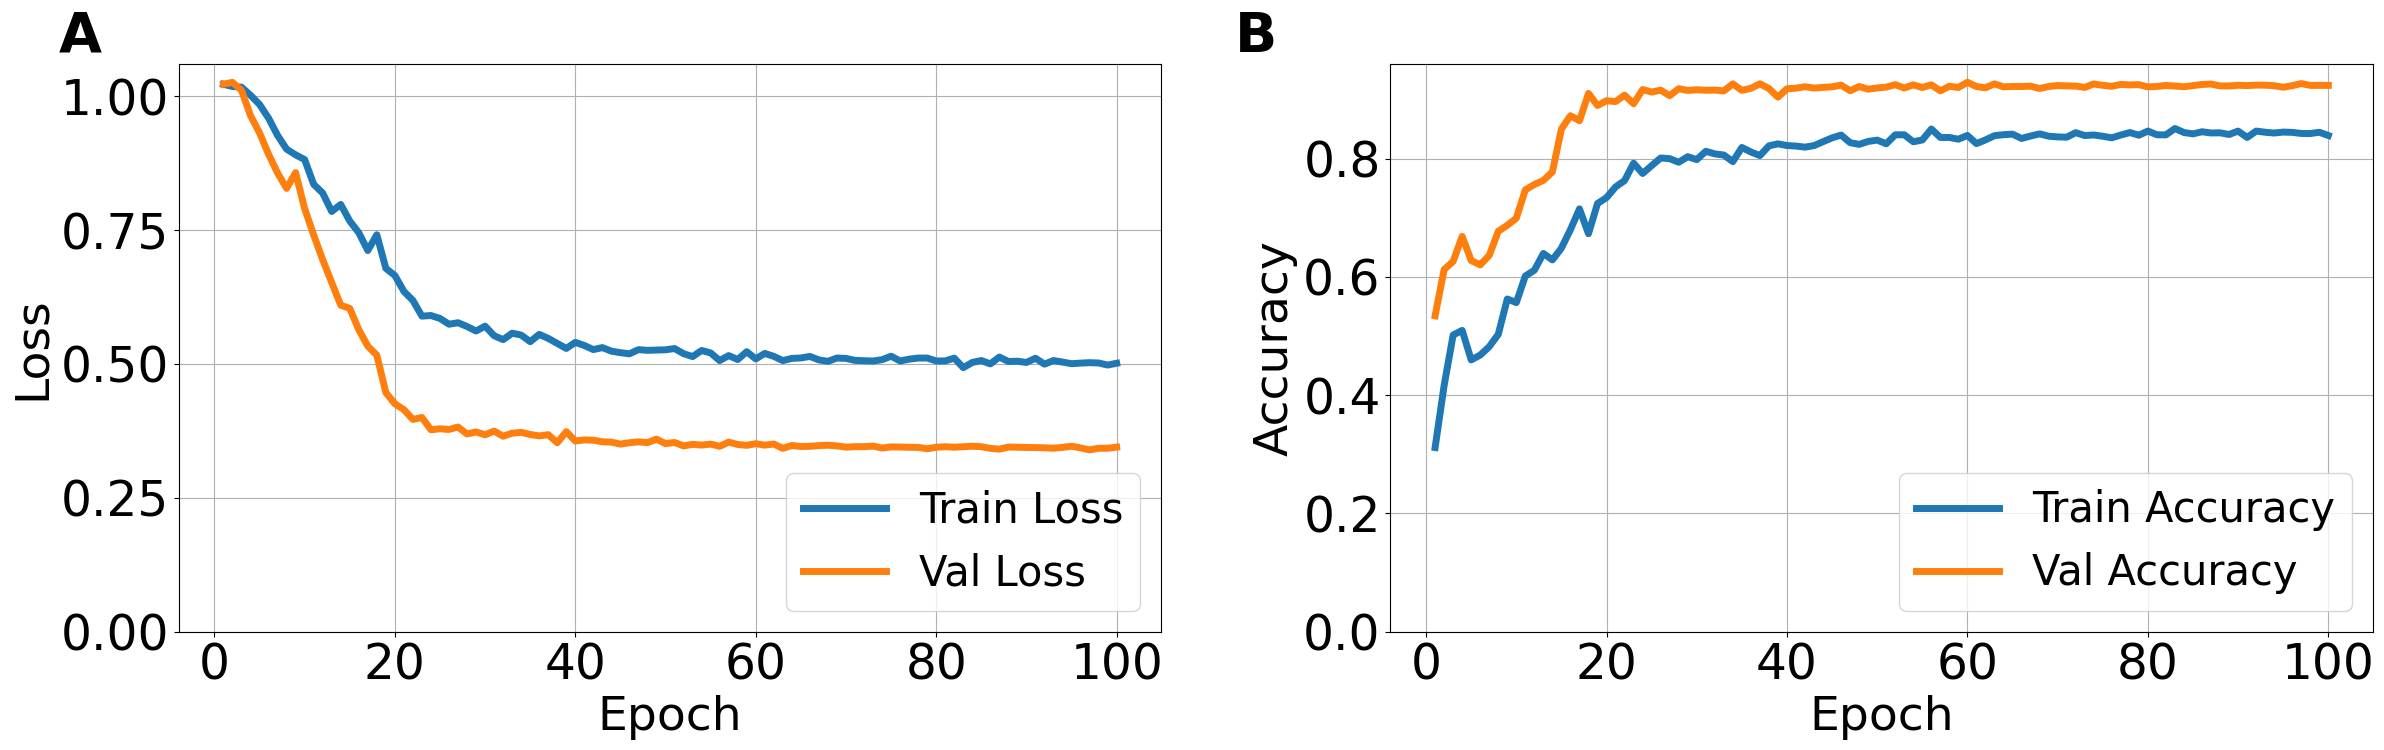

In [ ]:
# --- Fixed font size ---
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 35,
    'ytick.labelsize': 35,
    'legend.fontsize': 30
})

epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Left plot: Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss', linewidth=5)
axes[0].plot(epochs, history['val_loss'], label='Val Loss', linewidth=5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(bottom=0)
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Right plot: Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train Accuracy', linewidth=5)
axes[1].plot(epochs, history['val_acc'], label='Val Accuracy', linewidth=5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(bottom=0)
axes[1].legend(loc='lower right')
axes[1].grid(True)

# --- Add OUTSIDE panel labels (A, B) ---
fig.text(0.02, 0.95, 'A', fontsize=40, fontweight='bold', va='top', ha='left')
fig.text(0.51, 0.95, 'B', fontsize=40, fontweight='bold', va='top', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.92], w_pad=3)  # leave space for top labels
plt.savefig("grapha6.svg", bbox_inches='tight')
plt.show()

In [ ]:
def dice_per_class(y_true, y_pred, num_classes):
    assert y_true.shape == y_pred.shape, f"Shapes must match: {y_true.shape} vs {y_pred.shape}"
    dices = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).float()
        y_pred_cls = (y_pred == cls).float()

        intersection = (y_true_cls * y_pred_cls).sum()
        union = y_true_cls.sum() + y_pred_cls.sum()
        dice = (2 * intersection) / (union + 1e-6)
        dices.append(dice.item())
    mean_dice = sum(dices) / num_classes
    return mean_dice, dices

# Convert outputs to class indices
y_pred = torch.argmax(outputs, dim=1)  # (B, H, W)
y_true = torch.argmax(masks, dim=1)                   # (B, H, W) already integer labels

# Compute Dice
mean_dice_val, class_dice_list = dice_per_class(y_true, y_pred, num_classes=7)

# Class names for your retinal layers
class_names = [
    "Choroid",
    "GCL + IPL",
    "INL + OPL",
    "ONL + ELM",
    "PR + RPE",
    "RNFL",
    "Background"
]

print(f"Mean Dice: {mean_dice_val:.4f}")
for name, dice in zip(class_names, class_dice_list):
    print(f"{name} Dice: {dice:.4f}")

Mean Dice: 0.9383
Choroid Dice: 0.8439
GCL + IPL Dice: 0.9674
INL + OPL Dice: 0.9491
ONL + ELM Dice: 0.9754
PR + RPE Dice: 0.9705
RNFL Dice: 0.8927
Background Dice: 0.9692


In [ ]:
# Pick test image
test_img_number = 7
test_img = X_test[test_img_number]      # (1, H, W)
ground_truth_img = y_test_tensor[test_img_number]   # (H, W), already class indices

# Convert to torch tensor and add batch dimension for model
test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


# Make prediction
model.eval()
with torch.no_grad():
    output = model(test_img_input)           # (1, num_classes, H, W)
    prediction = torch.argmax(output, dim=1)  # (1, H, W)

predicted_img = prediction[0].cpu().numpy()  # (H, W)

C:\Users\sandi\AppData\Local\Temp\ipykernel_31972\605959455.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


In [ ]:
# Original size and crop
orig_h, orig_w = 1024, 245  # original pixels
orig_mm_h, orig_mm_w = 2, 3 # mm

# Cropped size
crop_h, crop_w = 512, 240   # after your cropping
# Pixel size in mm
pixel_size_x = orig_mm_w / orig_w   # mm per pixel in x
pixel_size_y = orig_mm_h / orig_h   # mm per pixel in y

print (pixel_size_x)
print (pixel_size_y)


0.012244897959183673
0.001953125


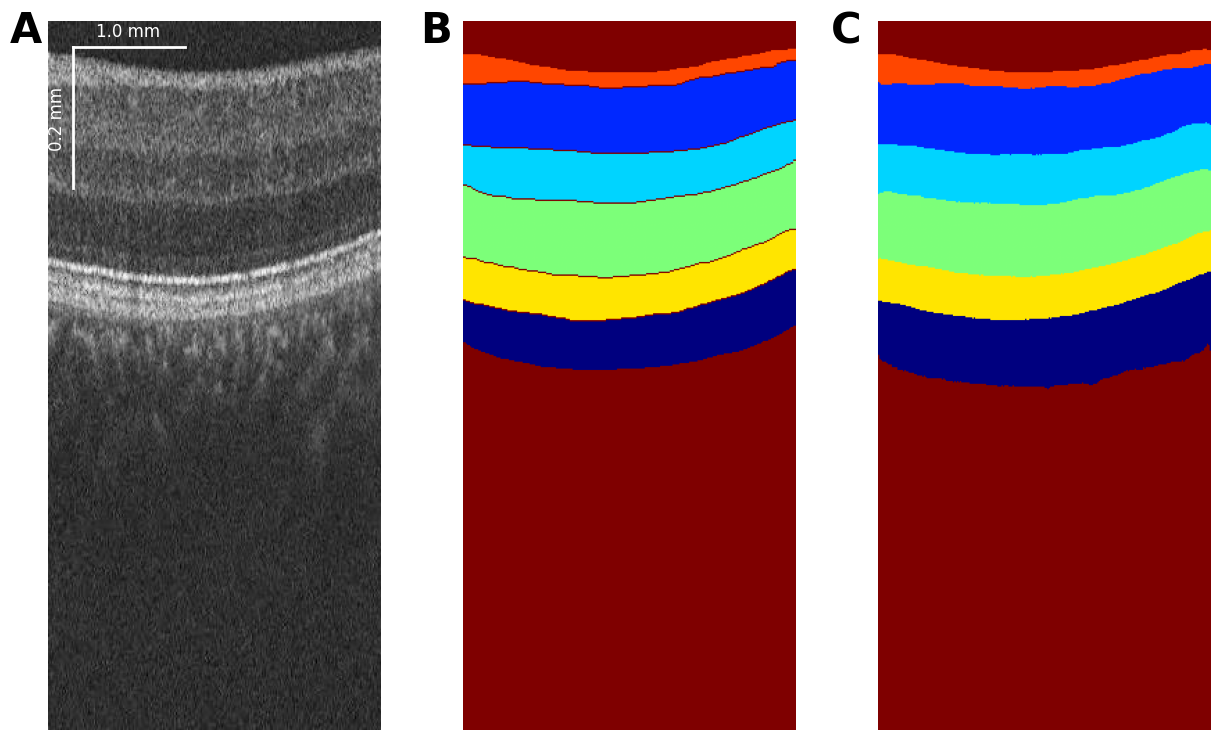

In [ ]:
# Compute pixels for scale
scale_x_mm = 1.0
scale_y_mm = 0.2
scale_x_px = int(scale_x_mm / pixel_size_x)
scale_y_px = int(scale_y_mm / pixel_size_y)

x0, y0 = 18, 18

fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# --- A: Test image ---
ax[0].imshow(test_img[0], cmap='gray')
ax[0].axis('off')

ax[0].add_line(plt.Line2D([x0, x0 + scale_x_px], [y0, y0], color='white', linewidth=2))
ax[0].add_line(plt.Line2D([x0, x0], [y0, y0 + scale_y_px], color='white', linewidth=2))

ax[0].text(x0 + scale_x_px//2, y0 - 5, f'{scale_x_mm} mm',
           color='white', ha='center', va='bottom', fontsize=12)
ax[0].text(x0 - 5, y0 + scale_y_px//2, f'{scale_y_mm} mm',
           color='white', ha='right', va='center', fontsize=12, rotation=90)

# --- B ---
ax[1].imshow(ground_truth_img, cmap='jet')
ax[1].axis('off')

# --- C ---
ax[2].imshow(predicted_img, cmap='jet')
ax[2].axis('off')

# ---- PERFECTLY ALIGNED OUTSIDE LABELS ----
for i, label in enumerate(['A', 'B', 'C']):
    pos = ax[i].get_position()
    fig.text(
        pos.x0 - 0.025, pos.y1 - 0.04, label,
        fontsize=30, fontweight='bold',
        ha='left', va='bottom'
    )

plt.subplots_adjust(wspace=0.25)

plt.savefig("preda6.svg", bbox_inches='tight')
plt.show()

train_images.shape (198, 512, 320, 1)
<class 'numpy.ndarray'>


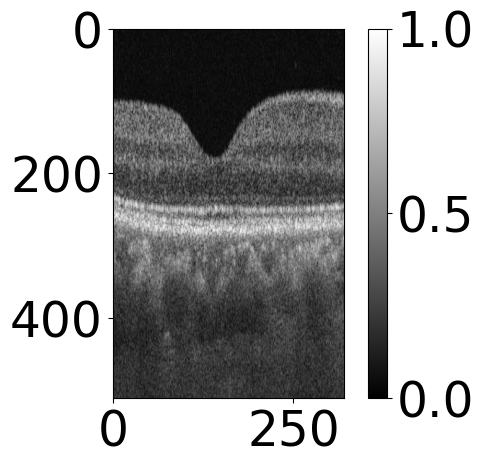

In [ ]:
# Path to test images
x_plex_path = r"D:\plex_OCT"
y_plex_path = r"D:\plex_masks"

#prepare training x (original) images
train_x_images = []

for directory_path in glob.glob(x_plex_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (320, 512))
        train_x_images.append(img)

train_x_images = np.array(train_x_images, dtype=np.float32)   #using float32 for PyTorch
train_x_images = train_x_images / 255.0
train_x_images = np.expand_dims(train_x_images, axis=-1)

print("train_images.shape", train_x_images.shape)
print(type(train_x_images))

plt.imshow(train_x_images[0], cmap='gray')
plt.colorbar()


In [ ]:
#loading and checking y (masks) data
train_y_images = []

for directory_path in glob.glob(y_plex_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (320, 512))
        train_y_images.append(img)

train_y_images = np.array(train_y_images, dtype=np.float32)   #using float32 for PyTorch
train_y_images = train_y_images / 255.0
train_y_images = np.expand_dims(train_y_images, axis=-1)

print("train_masks.shape", train_y_images.shape)
print(type(train_y_images))

train_masks.shape (1188, 512, 320, 1)
<class 'numpy.ndarray'>


(198, 512, 320, 7)
train_y_masks.shape (198, 512, 320, 7)
train_y_masks.shape (after processing) (198, 512, 320)
<class 'numpy.ndarray'>


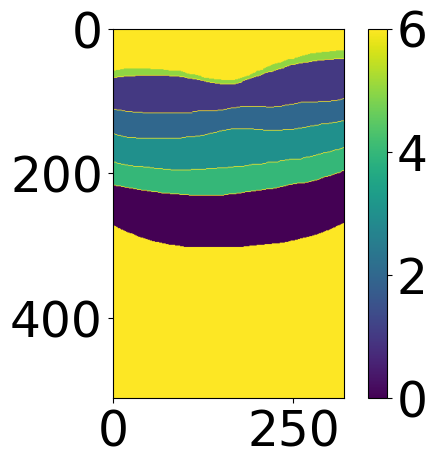

In [ ]:
# extra processing for masks, reducing number of masks to 1 mask per img
n_total_masks = train_y_images.shape[0]
n_samples = n_total_masks // 6

train_y_masks = np.zeros((n_samples,512,320,7))
print(train_y_masks.shape)

for i in range(6):
    x = np.arange(i,n_samples*6,6)
    train_y_masks[:, :, :, i] = train_y_images[x,:,:,0]


train_y_masks[:, :, :, 6] = 1 - train_y_masks[:, :, :, :6].max(axis=-1)   # adding background as a class
print("train_y_masks.shape", train_y_masks.shape)

train_y_masks = np.argmax(train_y_masks, axis=-1)  # needed for later classification, if not will only show binary classes
print("train_y_masks.shape (after processing)",train_y_masks.shape)

print(type(train_y_masks))
plt.imshow(train_y_masks[8])
plt.colorbar()

In [ ]:
# Convert masks to tensors and one-hot
y_train_tensor = torch.as_tensor(train_y_masks, dtype=torch.long)
y_train_cat = F.one_hot(y_train_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

# Convert images to tensors and permute
X_train = torch.tensor(train_x_images, dtype=torch.float32).permute(0, 3, 1, 2)

print(f"X_train shape: {X_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")

X_train shape: torch.Size([198, 1, 512, 320])
y_train_cat shape: torch.Size([198, 7, 512, 320])


In [ ]:
# Pick test image
test_img_number = 7
test_img = X_train[test_img_number]      # (1, H, W)
ground_truth_img = y_train_tensor[test_img_number]   # (H, W), already class indices

# Convert to torch tensor and add batch dimension for model
test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


# Make prediction
model.eval()
with torch.no_grad():
    output = model(test_img_input)           # (1, num_classes, H, W)
    prediction = torch.argmax(output, dim=1)  # (1, H, W)

predicted_img = prediction[0].cpu().numpy()  # (H, W)

C:\Users\sandi\AppData\Local\Temp\ipykernel_31972\2303263935.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


In [ ]:
# Original size and crop
orig_h, orig_w = 1536, 300  # original pixels
orig_mm_h, orig_mm_w = 3, 3 # mm

# Cropped size
crop_h, resize_w = 512, 320   # after your cropping

# Pixel size in mm
pixel_size_x = orig_mm_w / orig_w   # mm per pixel in x
pixel_size_y = orig_mm_h / orig_h   # mm per pixel in y

print (pixel_size_x)
print (pixel_size_y)


0.01
0.001953125


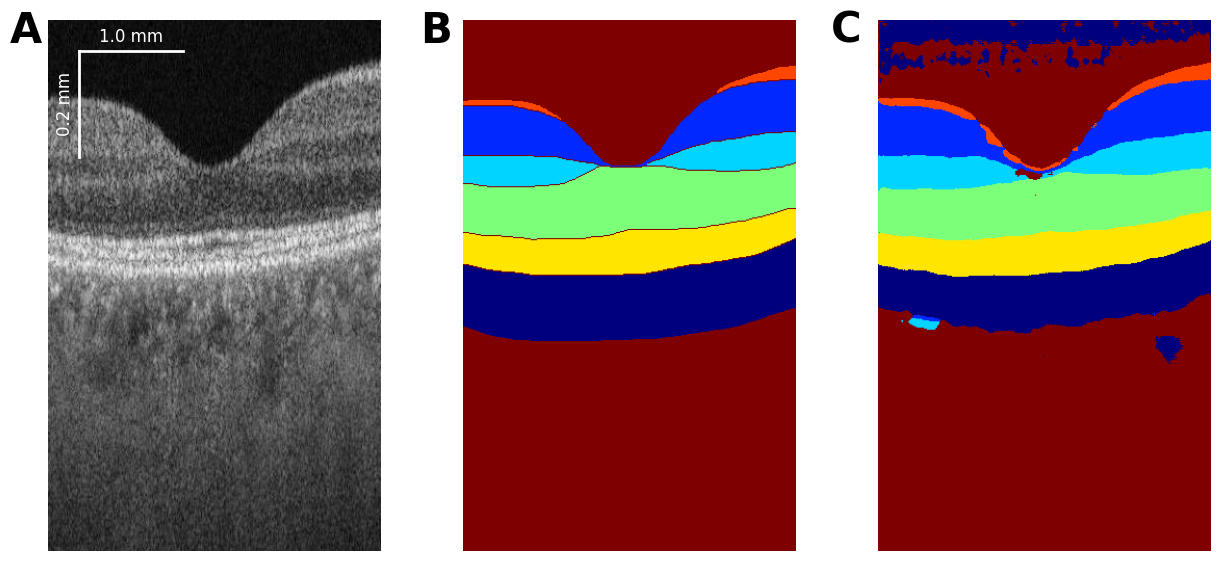

In [ ]:
# Compute pixels for scale
scale_x_mm = 1.0
scale_y_mm = 0.2
scale_x_px = int(scale_x_mm / pixel_size_x)
scale_y_px = int(scale_y_mm / pixel_size_y)

x0, y0 = 30, 30

fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# --- A: Test image ---
ax[0].imshow(test_img[0], cmap='gray')
ax[0].axis('off')

ax[0].add_line(plt.Line2D([x0, x0 + scale_x_px], [y0, y0], color='white', linewidth=2))
ax[0].add_line(plt.Line2D([x0, x0], [y0, y0 + scale_y_px], color='white', linewidth=2))

ax[0].text(x0 + scale_x_px//2, y0 - 5, f'{scale_x_mm} mm',
           color='white', ha='center', va='bottom', fontsize=12)
ax[0].text(x0 - 5, y0 + scale_y_px//2, f'{scale_y_mm} mm',
           color='white', ha='right', va='center', fontsize=12, rotation=90)

# --- B ---
ax[1].imshow(ground_truth_img, cmap='jet')
ax[1].axis('off')

# --- C ---
ax[2].imshow(predicted_img, cmap='jet')
ax[2].axis('off')

# ---- PERFECTLY ALIGNED OUTSIDE LABELS ----
for i, label in enumerate(['A', 'B', 'C']):
    pos = ax[i].get_position()
    fig.text(
        pos.x0 - 0.025, pos.y1 - 0.04, label,
        fontsize=30, fontweight='bold',
        ha='left', va='bottom'
    )

plt.subplots_adjust(wspace=0.25)

plt.savefig("predb1.2.svg", bbox_inches='tight')
plt.show()

In [ ]:
def dice_per_class(y_true, y_pred, num_classes):
    """
    Computes Dice score per class for a single image.
    y_true, y_pred: (H, W), integer labels
    Returns: mean_dice, list of dice per class
    """
    dices = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).float()
        y_pred_cls = (y_pred == cls).float()

        intersection = (y_true_cls * y_pred_cls).sum()
        union = y_true_cls.sum() + y_pred_cls.sum()
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        dices.append(dice.item())

    mean_dice = sum(dices) / num_classes
    return mean_dice, dices

# Number of classes
num_classes = 7

# Convert ground truth to torch tensor if needed
if not isinstance(ground_truth_img, torch.Tensor):
    y_true = torch.tensor(ground_truth_img, dtype=torch.int64)
else:
    y_true = ground_truth_img

# Convert predicted mask to torch tensor
if not isinstance(predicted_img, torch.Tensor):
    y_pred = torch.tensor(predicted_img, dtype=torch.int64)
else:
    y_pred = predicted_img

# Compute Dice scores
mean_dice_val, class_dice_list = dice_per_class(y_true, y_pred, num_classes=num_classes)

# Class names
class_names = [
    "Choroid",
    "GCL + IPL",
    "INL + OPL",
    "ONL + ELM",
    "PR + RPE",
    "RNFL",
    "Background"
]

print(f"Mean Dice: {mean_dice_val:.4f}")
for name, dice in zip(class_names, class_dice_list):
    print(f"{name} Dice: {dice:.4f}")

Mean Dice: 0.8586
Choroid Dice: 0.7010
GCL + IPL Dice: 0.9451
INL + OPL Dice: 0.8779
ONL + ELM Dice: 0.9411
PR + RPE Dice: 0.9743
RNFL Dice: 0.6504
Background Dice: 0.9206
